# 27PNF1500 electrical steel core loss fitting

This notebook fits the AEDT/Maxwell electrical steel model using volumetric loss data (`P (W/m^3)`).

Model without DC bias:

`P_v = Kh*f*B^Y + Kc*(f*B)^2 + Ke*(f*B)^1.5`

`B` is the peak sinusoidal flux density in tesla, `f` is frequency in Hz, and `P_v` is W/m^3. `Kdc` needs separate DC-bias loss measurements, so it is set to `0.0` here.

In [67]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_data_folder():
    candidates = [Path.cwd(), Path.cwd() / "material"]
    for candidate in candidates:
        if (candidate / "27PNF1500_Pc_50Hz.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find 27PNF1500_Pc_*Hz.csv. Run this notebook from the repo root or material folder.")


data_folder = find_data_folder()
frequency_pattern = re.compile(r"27PNF1500_Pc_(\d+(?:\.\d+)?)Hz\.csv$", re.IGNORECASE)
curves = {}
for path in data_folder.glob("27PNF1500_Pc_*Hz.csv"):
    match = frequency_pattern.match(path.name)
    if match:
        curves[float(match.group(1))] = path

if len(curves) < 2:
    raise ValueError("At least two frequency curves are required; four or more are recommended.")

frames = []
required_columns = {"B (tesla)", "P (w/kg)", "P (W/m^3)"}
for frequency_hz, path in sorted(curves.items()):
    frame = pd.read_csv(path)
    frame.columns = [column.strip() for column in frame.columns]
    missing_columns = required_columns - set(frame.columns)
    if missing_columns:
        raise ValueError(f"{path.name} is missing columns: {sorted(missing_columns)}")

    frame = frame.rename(columns={"B (tesla)": "B_T", "P (w/kg)": "P_W_kg", "P (W/m^3)": "P_W_m3"})
    frame["frequency_Hz"] = frequency_hz
    frame["source"] = path.name
    frames.append(frame[["source", "frequency_Hz", "B_T", "P_W_kg", "P_W_m3"]])

data = pd.concat(frames, ignore_index=True).sort_values(["frequency_Hz", "B_T"]).reset_index(drop=True)

print("Using curves:")
for frequency_hz, path in sorted(curves.items()):
    print(f"  {frequency_hz:g} Hz: {path.name}")
print(f"Total points: {len(data)}")

data.head()

Using curves:
  50 Hz: 27PNF1500_Pc_50Hz.csv
  200 Hz: 27PNF1500_Pc_200Hz.csv
  400 Hz: 27PNF1500_Pc_400Hz.csv
Total points: 61


,source,frequency_Hz,B_T,P_W_kg,P_W_m3
0,27PNF1500_Pc_50Hz.csv,50.0,0.100000,0.016502,126.241042
1,27PNF1500_Pc_50Hz.csv,50.0,0.109056,0.019664,150.431635
2,27PNF1500_Pc_50Hz.csv,50.0,0.136629,0.029541,225.990234
3,27PNF1500_Pc_50Hz.csv,50.0,0.158599,0.039649,303.315110
4,27PNF1500_Pc_50Hz.csv,50.0,0.177828,0.048749,372.931273


In [68]:
# P(W/m^3) should equal P(W/kg) times material density.
density_check = data.assign(density_kg_m3=data["P_W_m3"] / data["P_W_kg"])
density_summary = density_check.groupby("frequency_Hz")["density_kg_m3"].agg(["mean", "min", "max", "std"])

reference_frequency = density_summary.index.min()
reference_density = density_summary.loc[reference_frequency, "mean"]
density_summary["diff_from_reference_%"] = 100.0 * (density_summary["mean"] - reference_density) / reference_density

for frequency_hz, row in density_summary.iterrows():
    if abs(row["diff_from_reference_%"]) > 5.0:
        print(
            f"WARNING: {frequency_hz:g} Hz density differs from {reference_frequency:g} Hz "
            f"by {row['diff_from_reference_%']:.1f}%. Check P(W/m^3) conversion."
        )

density_summary

,mean,min,max,std,diff_from_reference_%
frequency_Hz,,,,,
50.0,7650.0,7649.999997,7650.000003,1.242101e-06,0.000000e+00
200.0,7650.0,7649.999998,7650.000001,8.221701e-07,-5.812979e-09
400.0,7650.0,7649.999999,7650.000002,8.411066e-07,1.754671e-10


In [69]:
def model_loss(B_T, frequency_Hz, Kh, Kc, Ke, Y):
    B_T = np.asarray(B_T, dtype=float)
    frequency_Hz = np.asarray(frequency_Hz, dtype=float)
    return Kh * frequency_Hz * B_T**Y + Kc * (frequency_Hz * B_T) ** 2 + Ke * (frequency_Hz * B_T) ** 1.5


def nnls_by_active_sets(A, y):
    """Small non-negative least-squares solver for Kh, Kc, and Ke."""
    A = np.asarray(A, dtype=float)
    y = np.asarray(y, dtype=float)
    coefficient_count = A.shape[1]
    best_beta = np.zeros(coefficient_count)
    best_sse = np.inf

    for mask in range(1, 1 << coefficient_count):
        active = [index for index in range(coefficient_count) if mask & (1 << index)]
        beta_active, *_ = np.linalg.lstsq(A[:, active], y, rcond=None)
        if np.any(beta_active < -1e-12):
            continue

        beta = np.zeros(coefficient_count)
        beta[active] = np.maximum(beta_active, 0.0)
        residual = A @ beta - y
        sse = float(residual @ residual)
        if sse < best_sse:
            best_beta = beta
            best_sse = sse

    return best_beta


def fit_coefficients(data, y_bounds=(1.0, 3.0), grid_points=4001, objective="relative"):
    if objective not in {"relative", "absolute"}:
        raise ValueError('objective must be "relative" or "absolute"')

    B = data["B_T"].to_numpy(dtype=float)
    f = data["frequency_Hz"].to_numpy(dtype=float)
    P = data["P_W_m3"].to_numpy(dtype=float)
    weights = 1.0 / np.maximum(P, 1e-30) if objective == "relative" else np.ones_like(P)

    best = None
    for Y in np.linspace(y_bounds[0], y_bounds[1], grid_points):
        A = np.column_stack([f * B**Y, (f * B) ** 2, (f * B) ** 1.5])
        Kh, Kc, Ke = nnls_by_active_sets(A * weights[:, None], P * weights)
        predicted = model_loss(B, f, Kh, Kc, Ke, Y)
        relative_error = (predicted - P) / np.maximum(P, 1e-30)
        absolute_error = predicted - P
        score = np.sum(relative_error**2) if objective == "relative" else np.sum(absolute_error**2)

        if best is None or score < best["score"]:
            best = {
                "Kh": Kh,
                "Kc": Kc,
                "Ke": Ke,
                "Y": Y,
                "Kdc": 0.0,
                "predicted": predicted,
                "relative_error": relative_error,
                "absolute_error": absolute_error,
                "score": float(score),
            }

    best["rmse_W_m3"] = float(np.sqrt(np.mean(best["absolute_error"] ** 2)))
    best["relative_rmse"] = float(np.sqrt(np.mean(best["relative_error"] ** 2)))
    best["max_abs_relative_error"] = float(np.max(np.abs(best["relative_error"])))
    return best

In [70]:
# Relative error keeps the highest-loss 400 Hz points from dominating every coefficient.
fit = fit_coefficients(data, y_bounds=(1.0, 3.0), grid_points=4001, objective="relative")

coefficient_table = pd.DataFrame(
    [
        {"coefficient": "Kh", "value": fit["Kh"]},
        {"coefficient": "Kc", "value": fit["Kc"]},
        {"coefficient": "Ke", "value": fit["Ke"]},
        {"coefficient": "Y", "value": fit["Y"]},
        {"coefficient": "Kdc", "value": fit["Kdc"]},
    ]
)

print("Electrical steel core loss coefficients fitted with P in W/m^3")
for row in coefficient_table.itertuples(index=False):
    suffix = "  # no DC-bias data in the CSV files" if row.coefficient == "Kdc" else ""
    print(f"{row.coefficient:<3} = {row.value:.12g}{suffix}")

print()
print(f"relative RMSE      = {fit['relative_rmse']:.4%}")
print(f"RMSE               = {fit['rmse_W_m3']:.3f} W/m^3")
print(f"max relative error = {fit['max_abs_relative_error']:.4%}")

coefficient_table

Electrical steel core loss coefficients fitted with P in W/m^3
Kh  = 114.627472565
Kc  = 0.393877319969
Ke  = 0
Y   = 1.66
Kdc = 0  # no DC-bias data in the CSV files

relative RMSE      = 6.6198%
RMSE               = 2545.104 W/m^3
max relative error = 21.4412%


,coefficient,value
0,Kh,114.627473
1,Kc,0.393877
2,Ke,0.000000
3,Y,1.660000
4,Kdc,0.000000


In [71]:
fit_table = data.copy()
fit_table["P_fit_W_m3"] = fit["predicted"]
fit_table["error_W_m3"] = fit_table["P_fit_W_m3"] - fit_table["P_W_m3"]
fit_table["relative_error_%"] = 100.0 * fit["relative_error"]

fit_table.groupby("frequency_Hz").agg(
    points=("B_T", "count"),
    rmse_W_m3=("error_W_m3", lambda values: float(np.sqrt(np.mean(values**2)))),
    mean_abs_relative_error_percent=("relative_error_%", lambda values: float(np.mean(np.abs(values)))),
    max_abs_relative_error_percent=("relative_error_%", lambda values: float(np.max(np.abs(values)))),
)

,points,rmse_W_m3,mean_abs_relative_error_percent,max_abs_relative_error_percent
frequency_Hz,,,,
50.0,19,457.937563,5.391425,16.946789
200.0,21,1992.345844,6.235850,21.441249
400.0,21,3828.391073,3.940956,8.313804


y:\git\pyaedt_motor\material\27PNF1500_core_loss_fit_W_m3.png


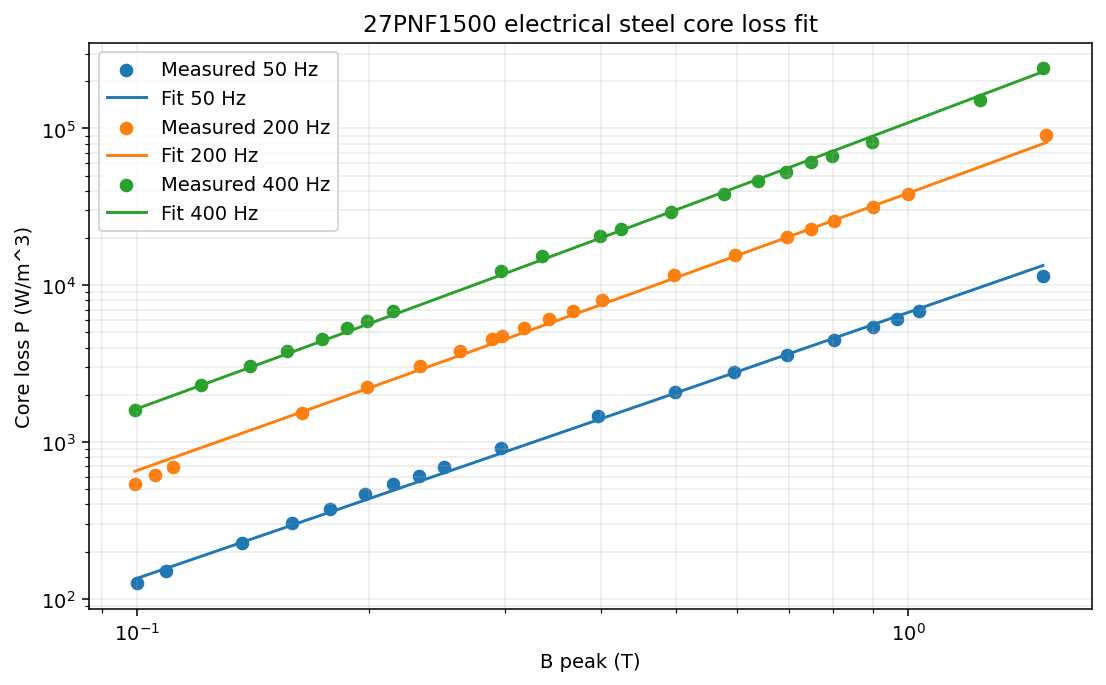

In [72]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=140)

for frequency_hz, group in data.groupby("frequency_Hz"):
    ax.scatter(group["B_T"], group["P_W_m3"], label=f"Measured {frequency_hz:g} Hz")
    B_line = np.linspace(group["B_T"].min(), group["B_T"].max(), 250)
    P_line = model_loss(B_line, frequency_hz, fit["Kh"], fit["Kc"], fit["Ke"], fit["Y"])
    ax.plot(B_line, P_line, label=f"Fit {frequency_hz:g} Hz")

ax.set_xlabel("B peak (T)")
ax.set_ylabel("Core loss P (W/m^3)")
ax.set_title("27PNF1500 electrical steel core loss fit")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(True, which='both', alpha=0.25)
ax.legend()
fig.tight_layout()

plot_path = data_folder / "27PNF1500_core_loss_fit_W_m3.png"
fig.savefig(plot_path, bbox_inches="tight")
print(plot_path)
plt.show()

In [73]:
# Optional: save the coefficients next to the CSV files.
output_path = data_folder / "27PNF1500_core_loss_coefficients_W_m3.csv"
coefficient_table.to_csv(output_path, index=False)
print(output_path)

y:\git\pyaedt_motor\material\27PNF1500_core_loss_coefficients_W_m3.csv
